---
---
# OPERATIONS TRACK

## 5. Operations Track

> **You may skip this section if you are focusing on the Data Science track.**

This section produces the following outputs — each corresponds to a slide in the deck:

| Output | What it shows | Slide |
|--------|--------------|-------|
| Temporal profiles (3 line charts) | Mean sales, stockout hours, and censoring share over 90 days | Slide 10 |
| City × group heatmap | Where stockouts concentrate geographically | Slide 11 |
| Availability bar chart | Which cities have the worst service levels | Slide 11 |
| Hourly stockout bar chart | How stockouts accumulate through the day | Slide 12 |
| Dual-axis time series | One product's sales overlaid with stockout hours | Slide 12 |

**A strong operations project** extends these starter visualizations into a focused analysis that answers one clear question (O1 or O2).

### 5a. EDA Strategy: Where to Look

In [ ]:
# --- Temporal profiles ---
daily_profile = history.groupby("day_idx").agg(
    mean_sales=("sale_amount", "mean"),
    mean_stockout_hours=("stock_hour6_22_cnt", "mean"),
    censored_share=("is_censored", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(daily_profile["day_idx"], daily_profile["mean_sales"], color="#B85042", linewidth=1.5)
axes[0].set_title("Mean daily sales over time")
axes[0].set_xlabel("Day index")
axes[0].set_ylabel("Mean sale_amount")

axes[1].plot(daily_profile["day_idx"], daily_profile["mean_stockout_hours"], color="#E8913A", linewidth=1.5)
axes[1].set_title("Mean stockout hours over time")
axes[1].set_xlabel("Day index")
axes[1].set_ylabel("Mean stock_hour6_22_cnt")

axes[2].plot(daily_profile["day_idx"], daily_profile["censored_share"], color="#5B8C5A", linewidth=1.5)
axes[2].set_title("Share of censored rows over time")
axes[2].set_xlabel("Day index")
axes[2].set_ylabel("Censored share")

plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

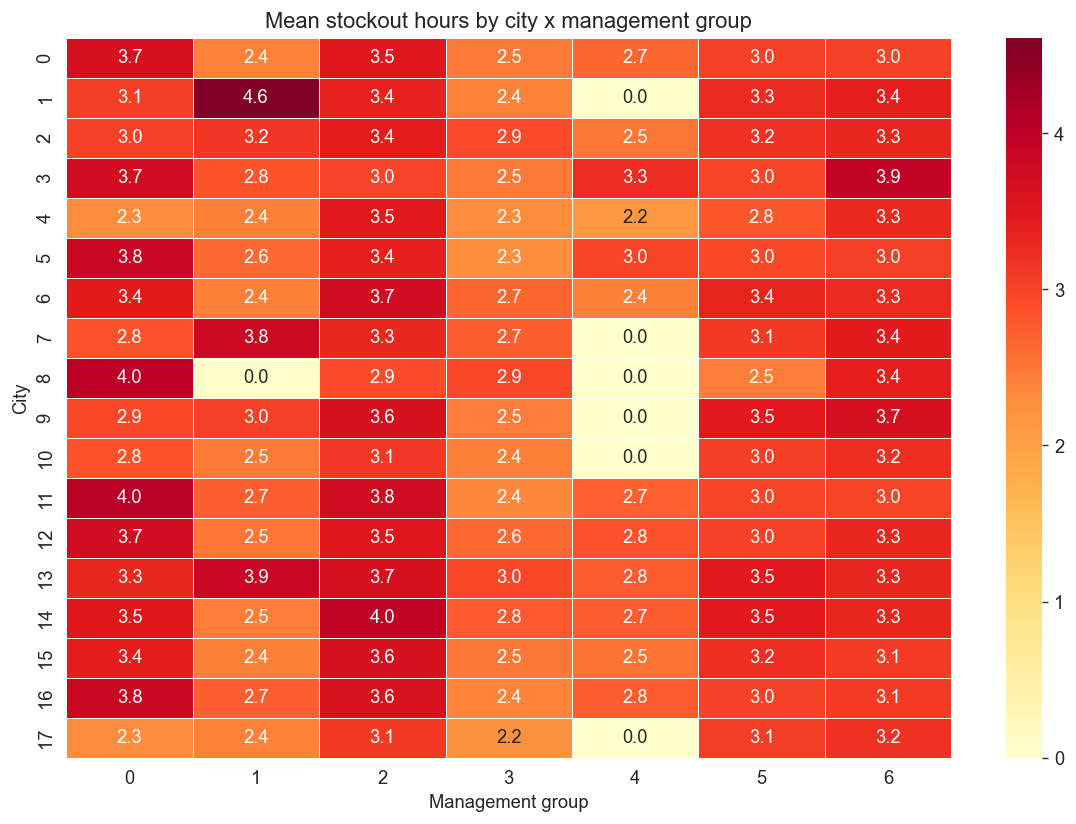

In [ ]:
# --- Heatmap: stockout hours by city x management group ---
heatmap_data = history.groupby(["city_id", "management_group_id"])["stock_hour6_22_cnt"].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt=".1f", ax=ax, linewidths=0.5)
ax.set_title("Mean stockout hours by city x management group")
ax.set_xlabel("Management group")
ax.set_ylabel("City")
plt.tight_layout()
plt.show()

### 5b. EDA Strategy: What to Measure

In [ ]:
# --- Operational KPIs per series ---
series_kpis = history.groupby("series_id").agg(
    psd=("sale_amount", "mean"),
    stockout_frequency=("is_censored", "mean"),
    mean_stockout_hours=("stock_hour6_22_cnt", "mean"),
    availability_rate=("censoring_severity", "mean"),
    city=("city_id", "first"),
    mgmt_group=("management_group_id", "first"),
).reset_index()

# Convert from mean censoring severity to availability rate
series_kpis["availability_rate"] = 1 - series_kpis["availability_rate"]

print("=== Series-level KPI summary ===")
display(series_kpis[["psd", "stockout_frequency", "mean_stockout_hours", "availability_rate"]].describe().round(3))

=== Series-level KPI summary ===


,psd,stockout_frequency,mean_stockout_hours,availability_rate
count,50000.000,50000.000,50000.000,50000.000
mean,0.999,0.443,3.180,0.801
std,1.153,0.148,1.314,0.082
min,0.222,0.056,0.622,0.030
25%,0.494,0.344,2.378,0.781
50%,0.658,0.422,2.828,0.823
75%,1.054,0.522,3.511,0.851
max,19.074,1.000,15.522,0.961


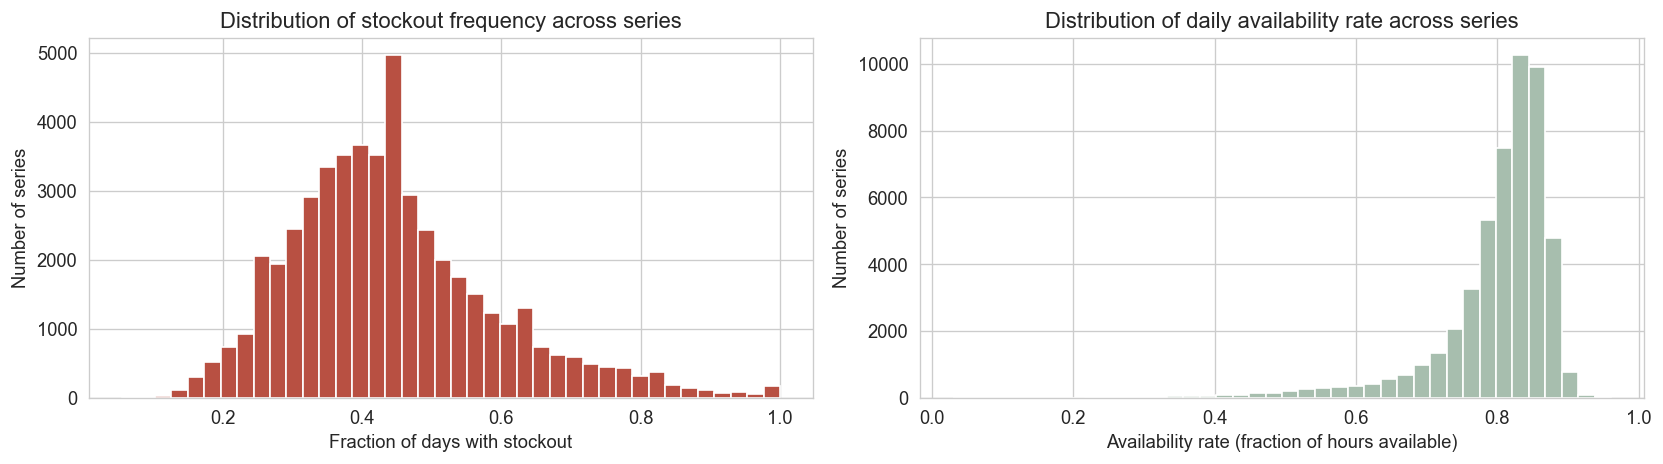

In [ ]:
# --- Distribution of stockout frequency and availability ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(series_kpis["stockout_frequency"], bins=40, color="#B85042", edgecolor="white")
axes[0].set_title("Distribution of stockout frequency across series")
axes[0].set_xlabel("Fraction of days with stockout")
axes[0].set_ylabel("Number of series")

axes[1].hist(series_kpis["availability_rate"], bins=40, color="#A7BEAE", edgecolor="white")
axes[1].set_title("Distribution of daily availability rate across series")
axes[1].set_xlabel("Availability rate (fraction of hours available)")
axes[1].set_ylabel("Number of series")

plt.tight_layout()
plt.show()

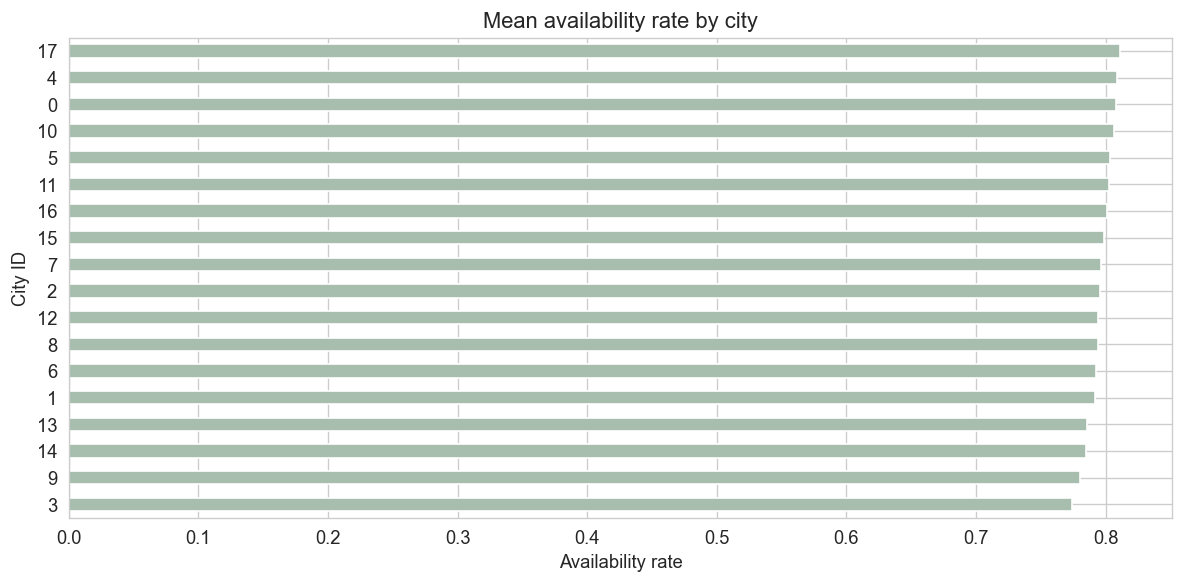

In [ ]:
# --- Availability by city ---
city_avail = series_kpis.groupby("city")["availability_rate"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
city_avail.plot(kind="barh", color="#A7BEAE", edgecolor="white", ax=ax)
ax.set_title("Mean availability rate by city")
ax.set_xlabel("Availability rate")
ax.set_ylabel("City ID")
plt.tight_layout()
plt.show()

### 5c. Hourly Stockout Patterns

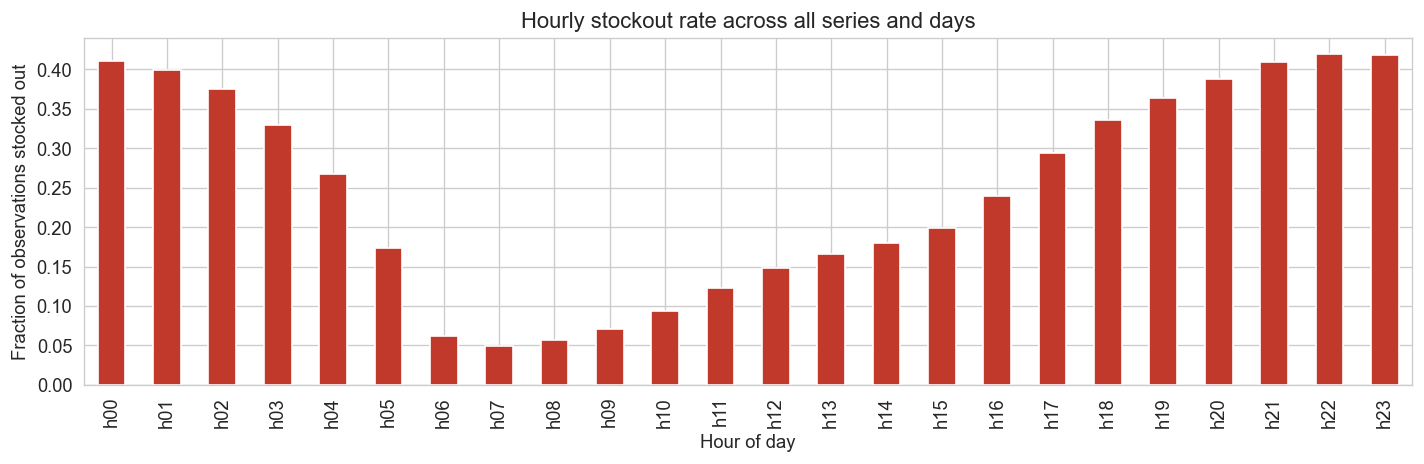

In [ ]:
# Expand hourly stock status to compute hourly stockout rates
hourly_stock = np.stack(history["hours_stock_status"].values)
hourly_labels = [f"h{h:02d}" for h in range(24)]
hourly_stockout_rate = pd.Series(hourly_stock.mean(axis=0), index=hourly_labels)

fig, ax = plt.subplots(figsize=(12, 4))
hourly_stockout_rate.plot(kind="bar", color="#C0392B", edgecolor="white", ax=ax)
ax.set_title("Hourly stockout rate across all series and days")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraction of observations stocked out")
plt.tight_layout()
plt.show()

### 5d. Example: One Product Over Time

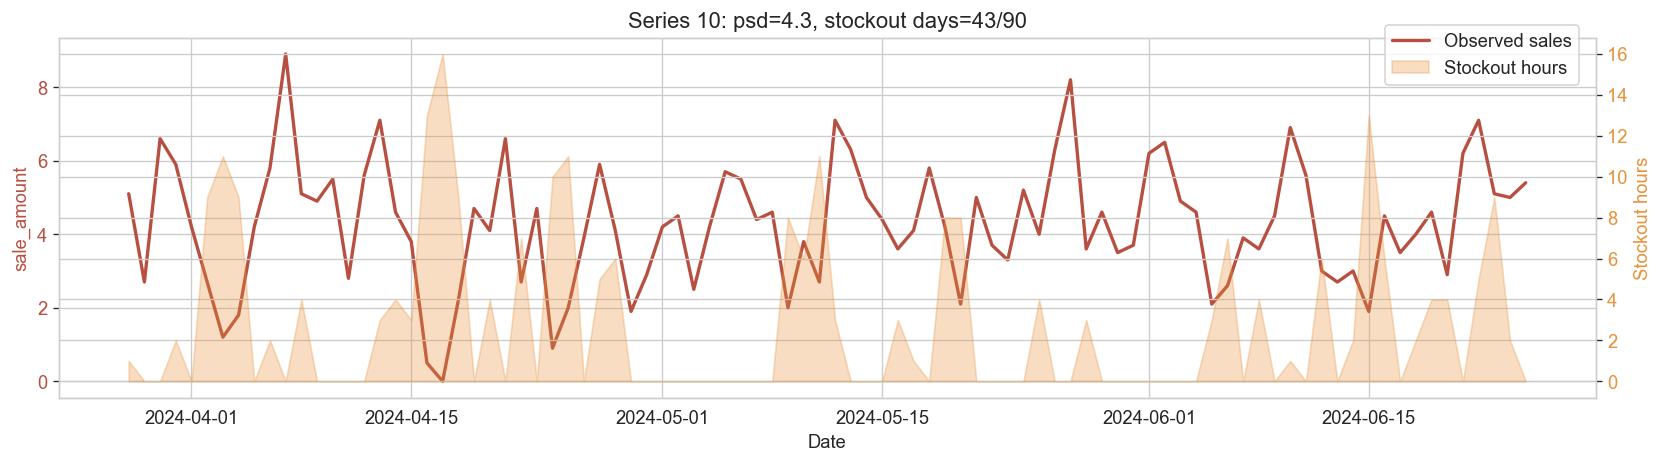

In [ ]:
# Pick a high-sale series with some stockouts
high_stockout = series_kpis[(series_kpis["psd"] > 3) & (series_kpis["stockout_frequency"] > 0.3)]
if len(high_stockout) > 0:
    example_sid2 = high_stockout.iloc[0]["series_id"]
else:
    example_sid2 = history.groupby("series_id")["psd"].first().idxmax()

example = history[history["series_id"] == example_sid2].copy()
n_days = len(example)

fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(example["dt"], example["sale_amount"], color="#B85042", linewidth=2, label="Observed sales")
ax1.set_xlabel("Date")
ax1.set_ylabel("sale_amount", color="#B85042")
ax1.tick_params(axis="y", labelcolor="#B85042")

ax2 = ax1.twinx()
ax2.fill_between(example["dt"], 0, example["stock_hour6_22_cnt"], alpha=0.3, color="#E8913A", label="Stockout hours")
ax2.set_ylabel("Stockout hours", color="#E8913A")
ax2.tick_params(axis="y", labelcolor="#E8913A")

ax1.set_title(f"Series {int(example_sid2)}: psd={example['psd'].iloc[0]:.1f}, stockout days={int(example['is_censored'].sum())}/{n_days}")
fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()

In [ ]:
# Re-split with recovered target
train_r, val_r = utils.time_split(history, horizon=7)

import forecast
importlib.reload(forecast)

history = forecast.add_seasonal_naive_forecast(
    history,
    data_col="recovered_daily_sales",
    pred_col="pred_recovered_naive",
    lag=7
)

history = forecast.add_seasonal_naive_forecast(
    history,
    data_col="sale_amount",
    pred_col="pred_seasonal_naive",
    lag=7
)

# Evaluate both
d2_results = {}
for method, col in [("Seasonal naive (raw)", "pred_seasonal_naive"), ("Seasonal naive (recovered)", "pred_recovered_naive")]:
    val_r["prediction"] = val_r[col].clip(lower=0)
    d2_results[method] = evaluate_forecast(val_r)

d2_df = pd.DataFrame(d2_results).T
print("=== D2 Recovery Comparison ===")
display(d2_df)

Train: day 1..83 (4,150,000 rows), Val: day 84..90 (350,000 rows)
=== D2 Recovery Comparison ===


,wape_overall,wape_low_sale,wape_high_sale,harmonic_mean,scored_rows
Seasonal naive (raw),0.3976,0.4830,0.3317,0.3947,198987.0
Seasonal naive (recovered),0.3765,0.4773,0.2986,0.3704,198987.0
